<a href="https://colab.research.google.com/github/Hamoudy91/CMPE-257/blob/main/Waymo_CBAM_FasterRCNN_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Waymo 2D Detection — Faster R-CNN (ResNet50-FPN) + CBAM (Option 2)
**Objective**: Train a modified detection model that reads **COCO JSON** + **images** directly (no YOLO TXT) and reports COCO mAP.


**References**
- TorchVision detection models (Faster R-CNN, FPN): https://pytorch.org/vision/stable/models.html#object-detection-instance-segmentation-and-person-keypoint-detection
- COCO evaluation protocol & API: https://cocodataset.org/#detection-eval , https://github.com/cocodataset/cocoapi
- CBAM paper (ECCV 2018): https://arxiv.org/abs/1807.06521


In [1]:
# @title Install compatible PyTorch + deps (CUDA 12.1)
!pip -q uninstall -y torch torchvision torchaudio >/dev/null

!pip -q install --index-url https://download.pytorch.org/whl/cu121 \
  torch==2.3.1+cu121 torchvision==0.18.1+cu121 torchaudio==2.3.1+cu121

!pip -q install pycocotools==2.0.7 albumentations==1.4.6 opencv-python==4.10.0.84 matplotlib==3.9.2 tqdm==4.67.1 pandas==2.2.2

import torch, torchvision, platform
print("Torch:", torch.__version__, " | TorchVision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available(), "| Python:", platform.python_version())

from torchvision.ops import nms
print("torchvision.nms OK")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 45.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 95.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 90.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 58.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 106.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 20.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 20.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# @title Mount Drive & set paths
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = "/content/drive/MyDrive/datasets"     # <-- adjust if needed
IMAGES_ZIP = "images (1).zip"                     # exact filename
COCO_JSON  = "annotations.json"                   # exact filename
OUT_ROOT   = "/content/drive/MyDrive/datasets/waymo_coco_workdir"

import os
os.makedirs(OUT_ROOT, exist_ok=True)

from pathlib import Path
print("JSON exists? ", Path(f"{DATA_ROOT}/{COCO_JSON}").exists())
print("ZIP exists?  ", Path(f"{DATA_ROOT}/{IMAGES_ZIP}").exists())
print("OUT_ROOT ok? ", Path(OUT_ROOT).exists())

Mounted at /content/drive
JSON exists?  True
ZIP exists?   True
OUT_ROOT ok?  True


In [3]:
# @title Unzip images (once) & count
from pathlib import Path
import glob

unz_root = f"{OUT_ROOT}/images_raw"
Path(unz_root).mkdir(parents=True, exist_ok=True)

if not any(Path(unz_root).iterdir()):
    !unzip -q "{DATA_ROOT}/{IMAGES_ZIP}" -d "{unz_root}"
else:
    print("images_raw already populated; skip unzip.")

imgs = sorted(glob.glob(f"{unz_root}/**/*.jpg", recursive=True) +
              glob.glob(f"{unz_root}/**/*.jpeg", recursive=True) +
              glob.glob(f"{unz_root}/**/*.png", recursive=True))
print("Found images:", len(imgs))
print("Sample:", imgs[:3])

images_raw already populated; skip unzip.
Found images: 10000
Sample: ['/content/drive/MyDrive/datasets/waymo_coco_workdir/images_raw/images/10017090168044687777_6380_000_6400_000_1_1550083467346370.jpg', '/content/drive/MyDrive/datasets/waymo_coco_workdir/images_raw/images/10017090168044687777_6380_000_6400_000_1_1550083467545990.jpg', '/content/drive/MyDrive/datasets/waymo_coco_workdir/images_raw/images/10017090168044687777_6380_000_6400_000_1_1550083467745665.jpg']


In [5]:
# Rebuild pycocotools to match the current NumPy ABI
!pip -q uninstall -y pycocotools
!pip -q install --no-binary=:all: cython==0.29.37
!pip -q install -U git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI

# Sanity check
import numpy as np, pycocotools
print("numpy:", np.__version__, "| pycocotools:", getattr(pycocotools, "__version__", "git-build"))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 14.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
numpy: 2.0.2 | pycocotools: git-build


In [6]:
import numpy as np
if not hasattr(np, "float"): np.float = np.float64
if not hasattr(np, "int"):   np.int   = np.int64
if not hasattr(np, "bool"):  np.bool  = np.bool_


In [3]:
from pycocotools.coco import COCO
import json
coco = COCO(f"{DATA_ROOT}/{COCO_JSON}")
print("Total images:", len(coco.imgs), "| Categories:", len(coco.getCatIds()), "| Annotations:", len(coco.getAnnIds()))


loading annotations into memory...
Done (t=1.46s)
creating index...
index created!
Total images: 10000 | Categories: 4 | Annotations: 230952


In [4]:
# @title Load COCO JSON & patch NumPy aliases if needed
import numpy as np
if not hasattr(np, "float"): np.float = np.float64
if not hasattr(np, "int"):   np.int   = np.int64
if not hasattr(np, "bool"):  np.bool  = np.bool_

from pycocotools.coco import COCO
import json
coco = COCO(f"{DATA_ROOT}/{COCO_JSON}")
print("Total images:", len(coco.imgs), "| Categories:", len(coco.getCatIds()), "| Annotations:", len(coco.getAnnIds()))

cats = coco.loadCats(coco.getCatIds())
class_names = [c["name"] for c in cats]
print("Classes:", class_names)

loading annotations into memory...
Done (t=0.85s)
creating index...
index created!
Total images: 10000 | Categories: 4 | Annotations: 230952
Classes: ['Vehicle', 'Pedestrian', 'Cyclist', 'Sign']


In [5]:
# @title COCO Dataset (direct JSON) + Albumentations
import torch, numpy as np, cv2, random, os
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
from pycocotools.coco import COCO

def get_train_tfms(img_size=1024):
    return A.Compose([
        A.LongestMaxSize(max_size=img_size, always_apply=True),
        A.PadIfNeeded(img_size, img_size, border_mode=0, value=0, always_apply=True),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ToFloat(max_value=255.0),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

def get_val_tfms(img_size=1024):
    return A.Compose([
        A.LongestMaxSize(max_size=img_size, always_apply=True),
        A.PadIfNeeded(img_size, img_size, border_mode=0, value=0, always_apply=True),
        A.ToFloat(max_value=255.0),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

class CocoDet(Dataset):
    def __init__(self, img_root, coco_api: COCO, ids, transforms=None):
        self.coco = coco_api
        self.img_root = Path(img_root)
        self.ids = ids
        self.tfms = transforms
        cats = self.coco.loadCats(self.coco.getCatIds())
        self.catid2contig = {c['id']: i+1 for i,c in enumerate(cats)}  # 1..K
        self.contig2catid = {i+1: c['id'] for i,c in enumerate(cats)}
        self.class_names = [c['name'] for c in cats]

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        info = self.coco.loadImgs(img_id)[0]
        fn = Path(info['file_name']).name
        fp = self.img_root / "images" / fn
        if not fp.exists():
            fp = self.img_root / fn
        im = cv2.cvtColor(cv2.imread(str(fp)), cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=img_id, iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)

        boxes, labels = [], []
        for a in anns:
            if 'bbox' not in a:
                continue
            x,y,w,h = a['bbox']
            if w <= 1 or h <= 1:
                continue
            boxes.append([x, y, x+w, y+h])
            labels.append(self.catid2contig[a['category_id']])

        if self.tfms:
            transformed = self.tfms(image=im, bboxes=np.array(boxes, np.float32), class_labels=np.array(labels, np.int64))
            im = transformed['image']
            boxes = torch.as_tensor(transformed['bboxes'], dtype=torch.float32)
            labels = torch.as_tensor(transformed['class_labels'], dtype=torch.int64)
        else:
            im = torch.from_numpy(im).permute(2,0,1).float()/255.0
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([img_id])}
        return im, target

ids = list(coco.imgs.keys())
random.seed(42); random.shuffle(ids)
split = int(0.8*len(ids))
train_ids, val_ids = ids[:split], ids[split:]

train_ds = CocoDet(f"{OUT_ROOT}/images_raw", coco, train_ids, transforms=get_train_tfms(1024))
val_ds   = CocoDet(f"{OUT_ROOT}/images_raw", coco, val_ids,   transforms=get_val_tfms(1024))

def collate_fn(batch): return tuple(zip(*batch))

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True,  num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=0, collate_fn=collate_fn, pin_memory=False)

xb, tb = next(iter(train_loader))
print("Train batch:", len(xb), "| image shape:", tuple(xb[0].shape), "| classes:", train_ds.class_names)

Train batch: 2 | image shape: (3, 1024, 1024) | classes: ['Vehicle', 'Pedestrian', 'Cyclist', 'Sign']


In [6]:
# @title StepBuild Faster R-CNN (ResNet50-FPN) + CBAM
import torch, torchvision
from torch import nn
from torchvision.models._utils import IntermediateLayerGetter
from torchvision.ops import FeaturePyramidNetwork
from torchvision.models.detection.faster_rcnn import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

device = 'cuda' if torch.cuda.is_available() else 'cpu'

class ChannelAttention(nn.Module):
    def __init__(self, in_ch, reduction=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_ch, in_ch//reuction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch//reuction, in_ch, 1, bias=False),
        )
        self.sig = nn.Sigmoid()
    def forward(self, x):
        return self.sig(self.mlp(self.avg(x)) + self.mlp(self.max(x)))

In [7]:
# @title (continued) — CBAM blocks and model (corrected)
import torch, torchvision
from torch import nn
from torchvision.models._utils import IntermediateLayerGetter
from torchvision.ops import FeaturePyramidNetwork
from torchvision.models.detection.faster_rcnn import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

device = 'cuda' if torch.cuda.is_available() else 'cpu'

class ChannelAttention(nn.Module):
    def __init__(self, in_ch, reduction=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_ch, in_ch//reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch//reduction, in_ch, 1, bias=False),
        )
        self.sig = nn.Sigmoid()
    def forward(self, x):
        return self.sig(self.mlp(self.avg(x)) + self.mlp(self.max(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel=7):
        super().__init__()
        self.conv = nn.Conv2d(2,1,kernel,padding=kernel//2,bias=False)
        self.sig = nn.Sigmoid()
    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        s = torch.cat([avg, mx], dim=1)
        return self.sig(self.conv(s))

class CBAM(nn.Module):
    def __init__(self, in_ch, reduction=16, spatial_kernel=7):
        super().__init__()
        self.ca = ChannelAttention(in_ch, reduction)
        self.sa = SpatialAttention(spatial_kernel)
    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class BottleneckCBAM(nn.Module):
    def __init__(self, bottleneck, use_cbam=True):
        super().__init__()
        self.body = bottleneck
        self.use_cbam = use_cbam
        if use_cbam:
            out_ch = bottleneck.conv3.out_channels
            self.cbam = CBAM(out_ch, reduction=16)
    def forward(self, x):
        y = self.body(x)
        return self.cbam(y) if self.use_cbam else y

def resnet50_fpn_cbam(use_cbam=True, trainable_layers=3):
    resnet = torchvision.models.resnet50(weights="IMAGENET1K_V2")
    for name in ['layer1','layer2','layer3','layer4']:
        layer = getattr(resnet, name)
        for i, m in enumerate(layer):
            if isinstance(m, torchvision.models.resnet.Bottleneck):
                layer[i] = BottleneckCBAM(m, use_cbam=use_cbam)
        setattr(resnet, name, layer)

    layers_to_train = ['layer4','layer3','layer2'][:trainable_layers]
    for n,p in resnet.named_parameters():
        if all([not n.startswith(L) for L in layers_to_train]) and not n.startswith('fc'):
            p.requires_grad_(False)

    return_layers = {'layer1':'0','layer2':'1','layer3':'2','layer4':'3'}
    in_channels_list = [256, 512, 1024, 2048]
    out_channels = 256

    body = IntermediateLayerGetter(resnet, return_layers=return_layers)
    fpn = FeaturePyramidNetwork(in_channels_list=in_channels_list, out_channels=out_channels)

    class BackboneWithFPN(nn.Module):
        def __init__(self, body, fpn):
            super().__init__()
            self.body = body; self.fpn = fpn; self.out_channels = out_channels
        def forward(self, x):
            feats = self.body(x)
            return self.fpn(feats)

    return BackboneWithFPN(body, fpn)

num_classes = len(train_ds.class_names)

backbone = resnet50_fpn_cbam(use_cbam=True, trainable_layers=3)
anchor_generator = AnchorGenerator(
    sizes=((32,), (64,), (128,), (256,)),             # 4 FPN levels
    aspect_ratios=((0.5,1.0,2.0),) * 4
)

model = FasterRCNN(
    backbone=backbone,
    num_classes=num_classes + 1,  # + background
    rpn_anchor_generator=anchor_generator,
    box_score_thresh=0.05,
    box_nms_thresh=0.5
).to(device)

sum_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Model on", device, "| classes:", num_classes, "| trainable params:", sum_params)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 139MB/s]


Model on cuda | classes: 4 | trainable params: 43633954


In [8]:
# @title Train, eval (single-process), save logs
import torch.nn.utils as U
from torch.optim import AdamW
import pandas as pd, time, json
from pycocotools.cocoeval import COCOeval

def filter_empty(xb, tb):
    keep_x, keep_t = [], []
    for x, t in zip(xb, tb):
        b = t.get("boxes", None)
        if b is None:
            continue
        if b.ndim == 1 and b.numel() == 0:
            continue
        if b.numel() == 0 or (b.shape[-1] != 4):
            continue
        keep_x.append(x)
        keep_t.append(t)
    return keep_x, keep_t

@torch.no_grad()
def coco_eval_singleprocess(model, ds, out_json_path, max_images=None, prog=True):
    model.eval()
    results = []
    ids = ds.ids if hasattr(ds, 'ids') else list(range(len(ds)))
    if max_images is not None:
        ids = ids[:max_images]
    t0 = time.time()
    for k, _ in enumerate(ids):
        img, target = ds[k]
        b = target.get("boxes", None)
        if b is not None and (b.numel() == 0 or (b.ndim == 1 and b.numel() == 0)):
            continue
        pred = model([img.to(device)])[0]
        if pred["boxes"].numel() == 0:
            continue
        for box, score, label in zip(pred["boxes"].cpu(), pred["scores"].cpu(), pred["labels"].cpu()):
            x1, y1, x2, y2 = box.tolist(); w, h = x2-x1, y2-y1
            cat_id = ds.contig2catid.get(int(label), None)
            if cat_id is None:
                continue
            results.append({
                "image_id": int(target["image_id"]),
                "category_id": int(cat_id),
                "bbox": [float(x1), float(y1), float(w), float(h)],
                "score": float(score)
            })
        if prog and (k+1) % 50 == 0:
            print(f"[eval] processed {k+1}/{len(ids)}")
    if not results:
        print("No detections produced."); return None
    with open(out_json_path, "w") as f:
        json.dump(results, f)
    coco_dt = ds.coco.loadRes(results)
    E = COCOeval(ds.coco, coco_dt, iouType='bbox')
    E.evaluate(); E.accumulate(); E.summarize()
    print(f"Eval time: {time.time()-t0:.1f}s on {len(ids)} images")
    return E.stats

EPOCHS = 5
LR = 2e-4
WD = 1e-4
VAL_N = 200

optimizer = AdamW([p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=WD)
history = []
best_ap = -1.0
best_path = f"{OUT_ROOT}/fasterrcnn_r50_fpn_cbam_best.pt"

iters_per_epoch = len(train_loader)
for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    t0 = time.time()
    for i, (xb, tb) in enumerate(train_loader):
        xb = [x.to(device) for x in xb]
        tb = [{k: v.to(device) for k, v in t.items()} for t in tb]
        xb, tb = filter_empty(xb, tb)
        if len(xb) == 0:
            continue
        loss_dict = model(xb, tb)
        loss = sum(loss_dict.values())
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        U.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
        optimizer.step()
        running += loss.item()
        if i % 20 == 0:
            print(f"Epoch {epoch}/{EPOCHS} | iter {i:04d}/{iters_per_epoch} | loss {loss.item():.4f}")
    stats = coco_eval_singleprocess(model, val_ds, f"{OUT_ROOT}/val_epoch{epoch}.json", max_images=VAL_N, prog=False)
    ap = float(stats[0]) if stats is not None else 0.0
    dur = time.time()-t0
    row = {"epoch": epoch, "train_loss": running/max(1,iters_per_epoch), "val_AP": ap, "time_s": dur}
    history.append(row)
    print(f"Epoch {epoch} done | avg_loss={row['train_loss']:.4f} | AP@[.5:.95]≈{ap:.4f} | time {dur:.1f}s")
    if ap > best_ap:
        best_ap = ap
        torch.save({"model": model.state_dict(), "epoch": epoch, "ap": ap, "class_names": train_ds.class_names}, best_path)
        print("Saved best:", best_path)

import pandas as pd
df = pd.DataFrame(history)
df.to_csv(f"{OUT_ROOT}/training_log.csv", index=False)
print(df)

Epoch 1/5 | iter 0000/4000 | loss 3.2825
Epoch 1/5 | iter 0020/4000 | loss 1.4965
Epoch 1/5 | iter 0040/4000 | loss 1.7485
Epoch 1/5 | iter 0060/4000 | loss 1.3993
Epoch 1/5 | iter 0080/4000 | loss 1.2832
Epoch 1/5 | iter 0100/4000 | loss 0.9821
Epoch 1/5 | iter 0120/4000 | loss 1.6001
Epoch 1/5 | iter 0140/4000 | loss 1.0659
Epoch 1/5 | iter 0160/4000 | loss 0.8552
Epoch 1/5 | iter 0180/4000 | loss 1.3073
Epoch 1/5 | iter 0200/4000 | loss 0.7682
Epoch 1/5 | iter 0220/4000 | loss 1.5055
Epoch 1/5 | iter 0240/4000 | loss 1.2688
Epoch 1/5 | iter 0260/4000 | loss 1.7064
Epoch 1/5 | iter 0280/4000 | loss 1.2219
Epoch 1/5 | iter 0300/4000 | loss 5.1375
Epoch 1/5 | iter 0320/4000 | loss 1.0125
Epoch 1/5 | iter 0340/4000 | loss 1.8395
Epoch 1/5 | iter 0360/4000 | loss 1.6077
Epoch 1/5 | iter 0380/4000 | loss 1.0040
Epoch 1/5 | iter 0400/4000 | loss 1.5897
Epoch 1/5 | iter 0420/4000 | loss 1.3483
Epoch 1/5 | iter 0440/4000 | loss 0.9310
Epoch 1/5 | iter 0460/4000 | loss 1.4532
Epoch 1/5 | iter

In [10]:
# Continue training for 10 more epochs
from torch.optim.lr_scheduler import StepLR
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

more_epochs = 10
for e in range(6, 6 + more_epochs):
    model.train()
    running = 0.0
    for i, (xb, tb) in enumerate(train_loader):
        xb = [x.to(device) for x in xb]
        tb = [{k: v.to(device) for k, v in t.items()} for t in tb]
        xb, tb = filter_empty(xb, tb)
        if not xb: continue
        loss_dict = model(xb, tb)
        loss = sum(loss_dict.values())
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], 1.0)
        optimizer.step()
        running += loss.item()
        if i % 20 == 0:
            print(f"Epoch {e} | Iter {i}/{len(train_loader)} | Loss {loss.item():.4f}")
    scheduler.step()
    stats = coco_eval_singleprocess(model, val_ds,
        f"{OUT_ROOT}/val_epoch{e}.json", max_images=200, prog=False)
    ap = float(stats[0]) if stats is not None else 0.0
    print(f"Epoch {e} done | avg_loss={running/len(train_loader):.4f} | AP@[.5:.95]={ap:.4f}")


Epoch 6 | Iter 0/4000 | Loss 0.8821
Epoch 6 | Iter 20/4000 | Loss 0.8997
Epoch 6 | Iter 40/4000 | Loss 0.9689
Epoch 6 | Iter 60/4000 | Loss 0.9811
Epoch 6 | Iter 80/4000 | Loss 0.7504
Epoch 6 | Iter 100/4000 | Loss 0.9399
Epoch 6 | Iter 120/4000 | Loss 0.7098
Epoch 6 | Iter 140/4000 | Loss 1.2207
Epoch 6 | Iter 160/4000 | Loss 0.8383
Epoch 6 | Iter 180/4000 | Loss 0.8491
Epoch 6 | Iter 200/4000 | Loss 0.7785
Epoch 6 | Iter 220/4000 | Loss 0.8807
Epoch 6 | Iter 240/4000 | Loss 0.8574
Epoch 6 | Iter 260/4000 | Loss 0.6669
Epoch 6 | Iter 280/4000 | Loss 0.9430
Epoch 6 | Iter 300/4000 | Loss 0.7408
Epoch 6 | Iter 320/4000 | Loss 0.9015
Epoch 6 | Iter 340/4000 | Loss 0.9111
Epoch 6 | Iter 360/4000 | Loss 1.4722
Epoch 6 | Iter 380/4000 | Loss 0.5666
Epoch 6 | Iter 400/4000 | Loss 1.1114
Epoch 6 | Iter 420/4000 | Loss 1.0718
Epoch 6 | Iter 440/4000 | Loss 0.3506
Epoch 6 | Iter 460/4000 | Loss 0.8370
Epoch 6 | Iter 480/4000 | Loss 0.9959
Epoch 6 | Iter 500/4000 | Loss 0.9567
Epoch 6 | Iter 520

,epoch,train_loss,val_AP,time_s
0,1,1.319628,0.000003,1989.778181
1,2,1.156818,0.000006,444.905509
2,3,1.057849,0.000011,448.951797
3,4,0.988587,0.000007,451.386914
4,5,0.939815,0.000004,445.582988


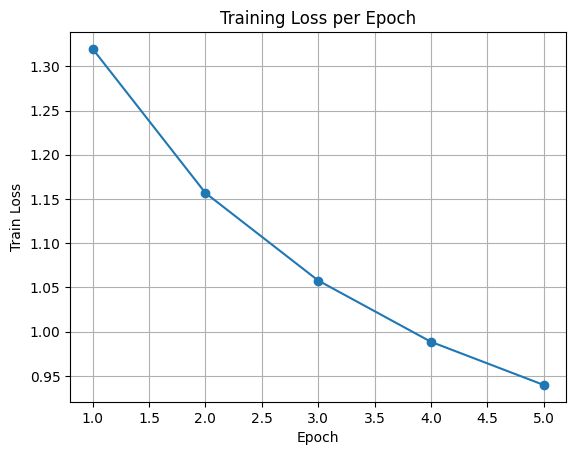

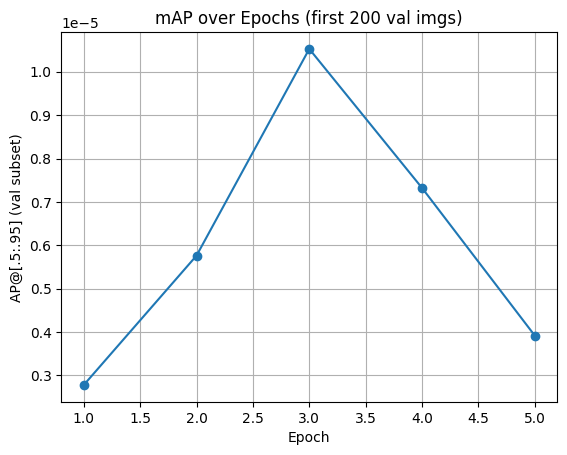

In [13]:
# @title Plot loss & AP curves
import pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

log_path = Path(f"{OUT_ROOT}/training_log.csv")
if log_path.exists():
    df = pd.read_csv(log_path)
    display(df)
    plt.figure(); plt.plot(df["epoch"], df["train_loss"], marker="o"); plt.xlabel("Epoch"); plt.ylabel("Train Loss"); plt.title("Training Loss per Epoch"); plt.grid(True); plt.show()
    plt.figure(); plt.plot(df["epoch"], df["val_AP"], marker="o"); plt.xlabel("Epoch"); plt.ylabel("AP@[.5:.95] (val subset)"); plt.title("mAP over Epochs (first 200 val imgs)"); plt.grid(True); plt.show()
else:
    print("No log found yet.")

In [12]:
stats_full = coco_eval_singleprocess(model, val_ds,
    f"{OUT_ROOT}/val_epoch15_full.json")


[eval] processed 50/2000
[eval] processed 100/2000
[eval] processed 150/2000
[eval] processed 200/2000
[eval] processed 250/2000
[eval] processed 300/2000
[eval] processed 350/2000
[eval] processed 400/2000
[eval] processed 450/2000
[eval] processed 500/2000
[eval] processed 550/2000
[eval] processed 600/2000
[eval] processed 650/2000
[eval] processed 700/2000
[eval] processed 750/2000
[eval] processed 800/2000
[eval] processed 850/2000
[eval] processed 900/2000
[eval] processed 950/2000
[eval] processed 1000/2000
[eval] processed 1050/2000
[eval] processed 1100/2000
[eval] processed 1150/2000
[eval] processed 1250/2000
[eval] processed 1300/2000
[eval] processed 1350/2000
[eval] processed 1400/2000
[eval] processed 1450/2000
[eval] processed 1500/2000
[eval] processed 1550/2000
[eval] processed 1600/2000
[eval] processed 1650/2000
[eval] processed 1700/2000
[eval] processed 1750/2000
[eval] processed 1800/2000
[eval] processed 1850/2000
[eval] processed 1900/2000
[eval] processed 1950

In [15]:
# Full-validation COCO mAP/AR (no subset cap)
full_stats = coco_eval_singleprocess(
    model, val_ds, f"{OUT_ROOT}/val_epoch15_full.json", max_images=None, prog=True
)
# COCO stats vector indices (for your report table):
# 0: AP@[.50:.95], 1: AP@.50, 2: AP@.75, 3: AP_small, 4: AP_medium, 5: AP_large,
# 6: AR@1, 7: AR@10, 8: AR@100, 9: AR_small, 10: AR_medium, 11: AR_large

if full_stats is not None:
    print({
        "AP@[.50:.95]": float(full_stats[0]),
        "AP@.50":       float(full_stats[1]),
        "AP@.75":       float(full_stats[2]),
        "AR@100":       float(full_stats[8]),
    })


[eval] processed 50/2000
[eval] processed 100/2000
[eval] processed 150/2000
[eval] processed 200/2000
[eval] processed 250/2000
[eval] processed 300/2000
[eval] processed 350/2000
[eval] processed 400/2000
[eval] processed 450/2000
[eval] processed 500/2000
[eval] processed 550/2000
[eval] processed 600/2000
[eval] processed 650/2000
[eval] processed 700/2000
[eval] processed 750/2000
[eval] processed 800/2000
[eval] processed 850/2000
[eval] processed 900/2000
[eval] processed 950/2000
[eval] processed 1000/2000
[eval] processed 1050/2000
[eval] processed 1100/2000
[eval] processed 1150/2000
[eval] processed 1250/2000
[eval] processed 1300/2000
[eval] processed 1350/2000
[eval] processed 1400/2000
[eval] processed 1450/2000
[eval] processed 1500/2000
[eval] processed 1550/2000
[eval] processed 1600/2000
[eval] processed 1650/2000
[eval] processed 1700/2000
[eval] processed 1750/2000
[eval] processed 1800/2000
[eval] processed 1850/2000
[eval] processed 1900/2000
[eval] processed 1950

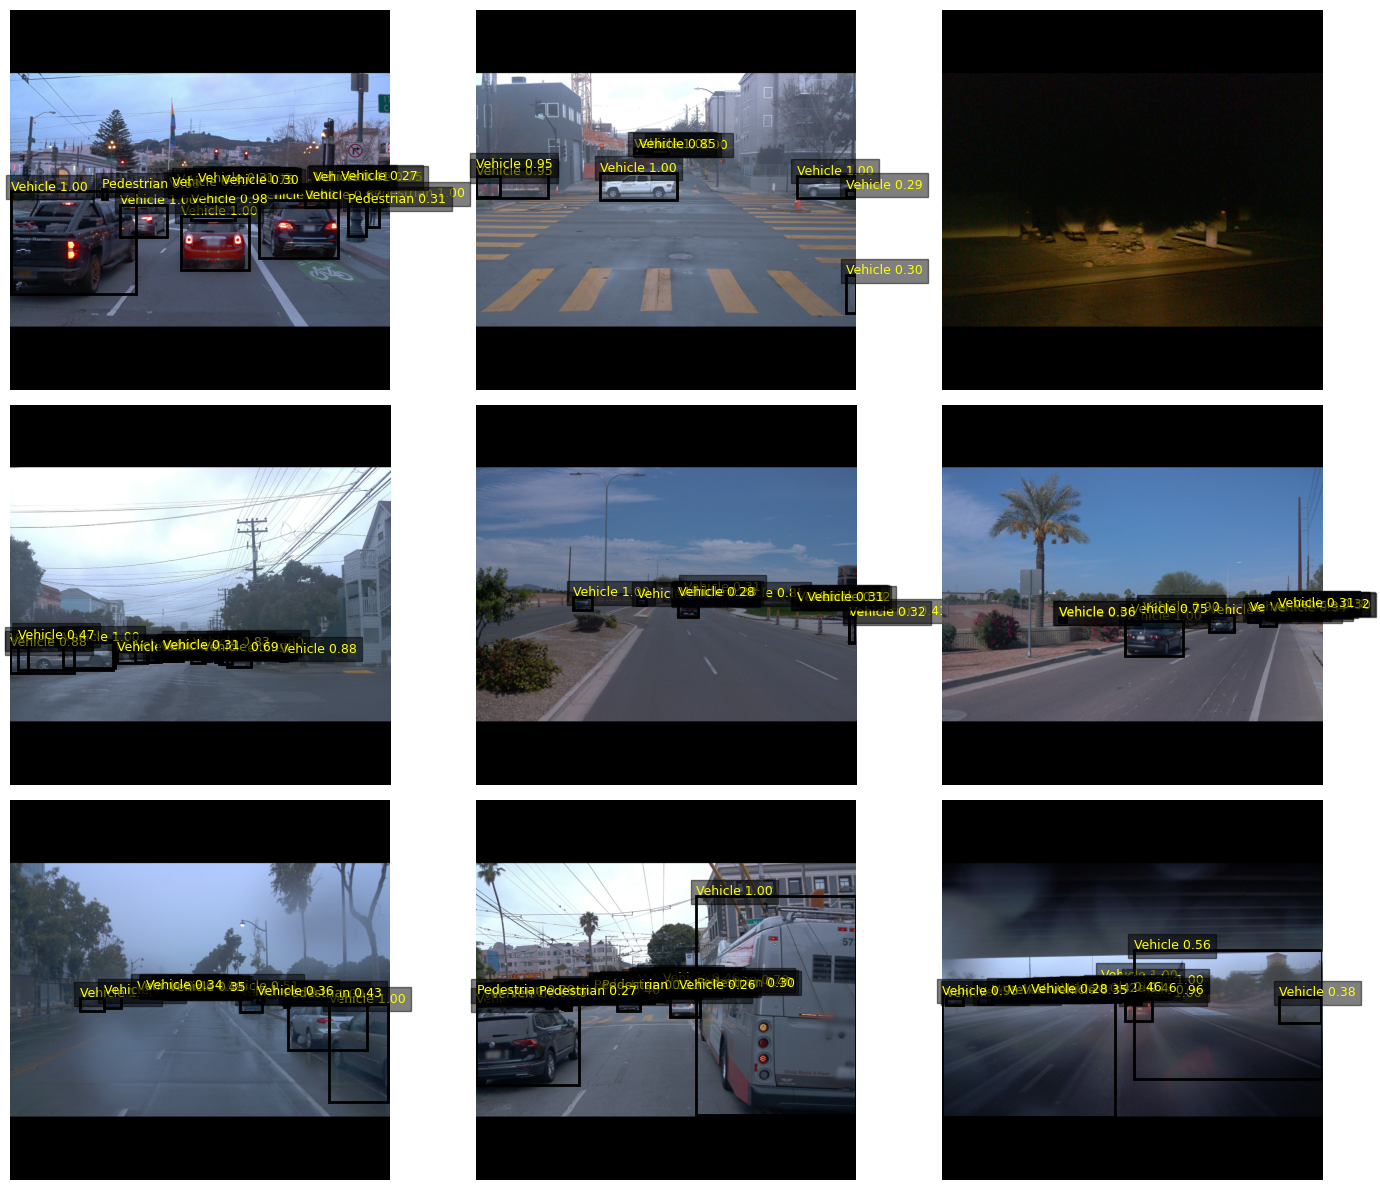

In [16]:
import random, matplotlib.pyplot as plt, matplotlib.patches as patches, torch

# simple visualizer for a few val images
def show_preds(ds, n=6, score_thr=0.25):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    ids = random.sample(range(len(ds)), n)
    cols = 3
    rows = (n + cols - 1)//cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4*rows))
    axes = axes.flatten()

    for ax, idx in zip(axes, ids):
        img, tgt = ds[idx]
        pred = model([img.to(device)])[0]
        im = img.permute(1,2,0).cpu().numpy()
        ax.imshow(im)
        # draw boxes
        for b, s, lab in zip(pred["boxes"].cpu(), pred["scores"].cpu(), pred["labels"].cpu()):
            if s < score_thr: continue
            x1,y1,x2,y2 = b.tolist()
            ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, linewidth=2))
            cname = ds.class_names[ds.contig2catid[int(lab)]-1]
            ax.text(x1, y1-2, f"{cname} {s:.2f}", color="yellow", fontsize=9, bbox=dict(fc="black", alpha=0.5))
        ax.set_axis_off()
    for j in range(len(ids), len(axes)):
        axes[j].set_axis_off()
    plt.tight_layout(); plt.show()

show_preds(val_ds, n=9, score_thr=0.25)


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=7.27s).
Accumulating evaluation results...
DONE (t=0.69s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

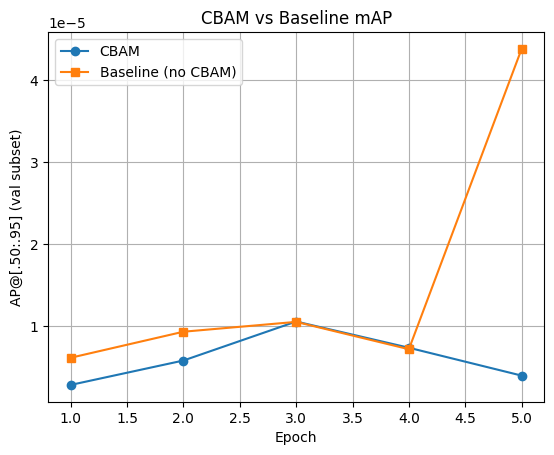

In [18]:
# Rebuild a baseline backbone (no CBAM) and model with the SAME settings
baseline_backbone = resnet50_fpn_cbam(use_cbam=False, trainable_layers=3)  # toggle
from torchvision.models.detection.rpn import AnchorGenerator
baseline_anchors = AnchorGenerator(sizes=((32,),(64,),(128,),(256,)),
                                   aspect_ratios=((0.5,1.0,2.0),)*4)
baseline = torchvision.models.detection.FasterRCNN(
    backbone=baseline_backbone,
    num_classes=len(train_ds.class_names)+1,
    rpn_anchor_generator=baseline_anchors,
    box_score_thresh=0.05, box_nms_thresh=0.5
).to(device)

# Train a few epochs (light) and log like before
import torch.nn.utils as U, time, pandas as pd
opt_b = torch.optim.AdamW([p for p in baseline.parameters() if p.requires_grad], lr=2e-4, weight_decay=1e-4)
hist_b = []
for e in range(1, 6):  # 5 quick epochs
    baseline.train(); t0=time.time(); run=0.0
    for xb, tb in train_loader:
        xb = [x.to(device) for x in xb]
        tb = [{k: v.to(device) for k,v in t.items()} for t in tb]
        xb, tb = filter_empty(xb, tb)
        if not xb: continue
        ld = baseline(xb, tb); loss = sum(ld.values())
        opt_b.zero_grad(set_to_none=True); loss.backward()
        U.clip_grad_norm_([p for p in baseline.parameters() if p.requires_grad], 1.0)
        opt_b.step(); run += loss.item()
    stats_b = coco_eval_singleprocess(baseline, val_ds, f"{OUT_ROOT}/val_baseline_e{e}.json", max_images=200, prog=False)
    ap_b = float(stats_b[0]) if stats_b is not None else 0.0
    hist_b.append({"epoch": e, "train_loss": run/len(train_loader), "val_AP": ap_b, "time_s": time.time()-t0})
df_b = pd.DataFrame(hist_b)
df_b.to_csv(f"{OUT_ROOT}/training_log_baseline.csv", index=False)
print(df_b.tail())

# Plot CBAM vs baseline AP (use your existing df_all for CBAM curve)
import pandas as pd, matplotlib.pyplot as plt
df_cbam = pd.read_csv(f"{OUT_ROOT}/training_log.csv")
plt.figure()
plt.plot(df_cbam["epoch"], df_cbam["val_AP"], marker="o", label="CBAM")
plt.plot(df_b["epoch"], df_b["val_AP"], marker="s", label="Baseline (no CBAM)")
plt.xlabel("Epoch"); plt.ylabel("AP@[.50:.95] (val subset)")
plt.title("CBAM vs Baseline mAP")
plt.grid(True); plt.legend(); plt.show()


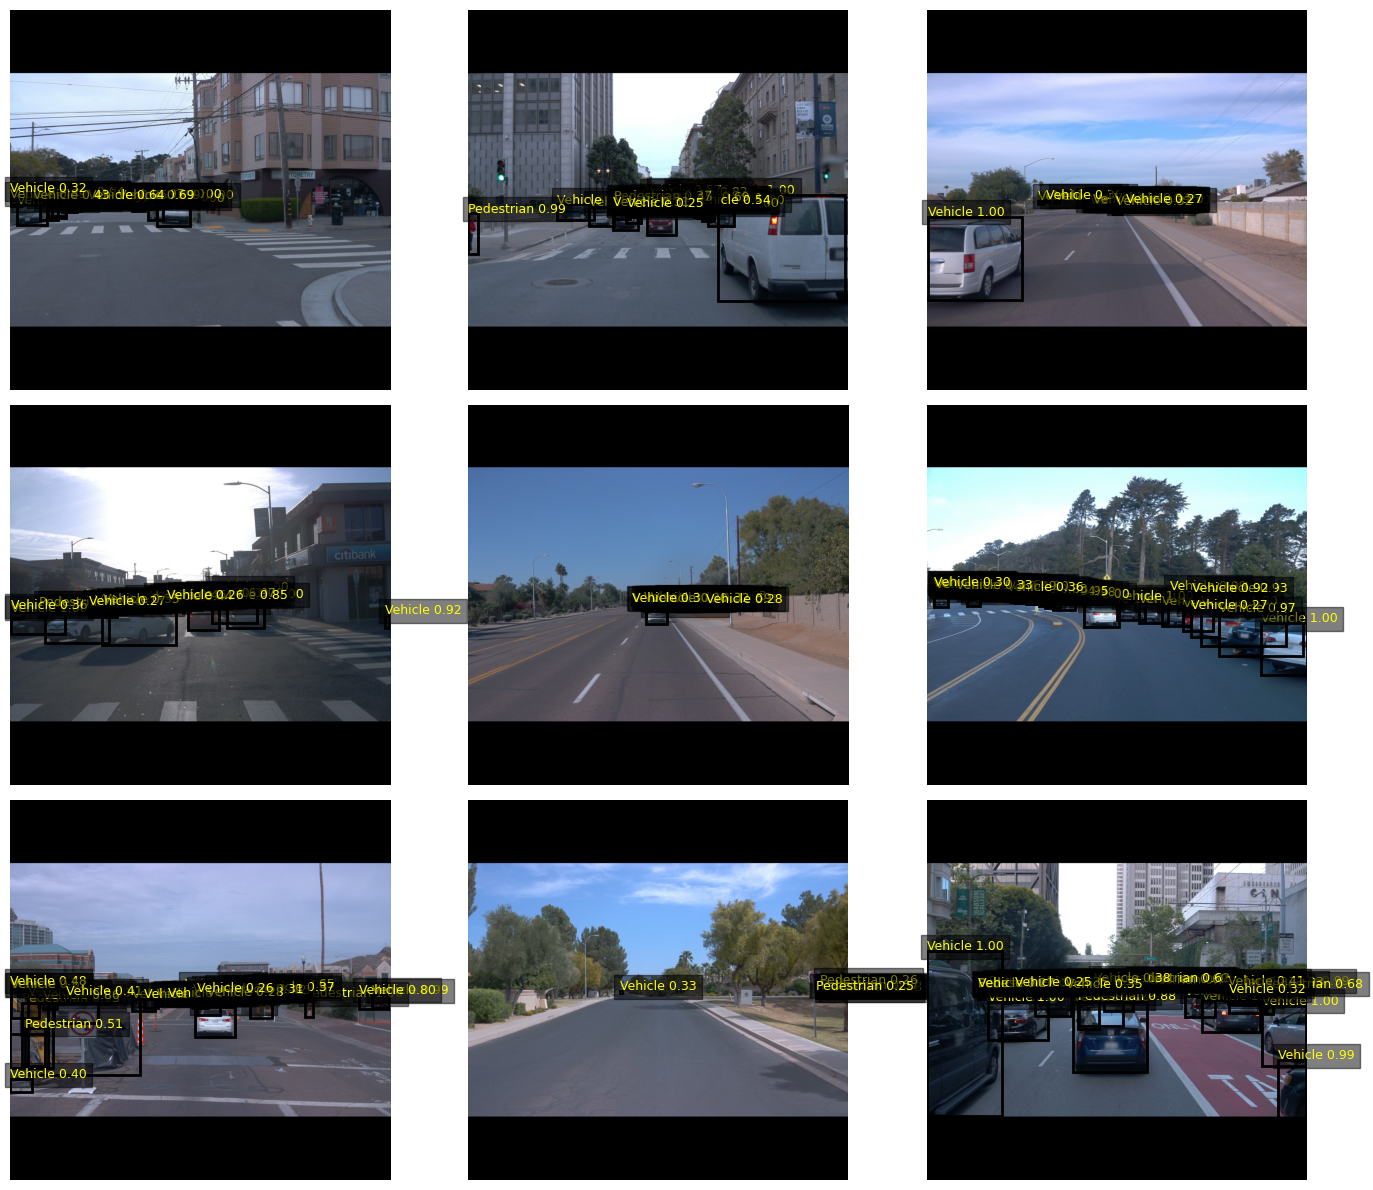

In [20]:
show_preds(val_ds, n=9, score_thr=0.25)
